
---

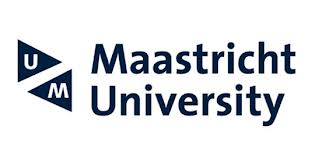

# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing - Tutorial Tokenization

⏱️ **Estimated time:** 1.6 hours – 3.5 hours


By Jan Scholtes


---

Version 2026-2027

---

Welcome to the tutorial on eXplainable Artificial Intelligence (XAI) in Natural Language Processing (NLP). In this notebook you will get introduced to different models and techniques used to explain and interpret NLP model decisions.

For this notebook we would need our GPU accelerator. Make sure you have selected the GPU runtime in Google Colab (Runtime > Change Runtime Type > T4 GPU).

## Learning Goals

After completing this tutorial, you will be able to:

- **Define** the concepts of transparency, interpretability, and explainability in the context of AI and NLP.
- **Apply** BERTViz to visualize and interpret attention patterns in Transformer models.
- **Use** saliency methods (Integrated Gradients) to identify important input features for model predictions.
- **Apply** LIME and SHAP to generate local explanations for NLP model predictions.
- **Understand** how adversarial attacks exploit model vulnerabilities and how to detect and defend against them.
- **Compare** different XAI techniques and assess their strengths and limitations for NLP tasks.

XAI requires:

**Transparency** is given “if the processes that extract model parameters from training data and generate labels from testing data can be described and motivated by the approach designer”.

**Interpretability** describes the possibility to comprehend the ML model and to present the underlying basis for decision-making in a way that is understandable to humans.

**Explainabilit**y is a concept that is recognized as important, but a joint definition is not yet available. It is suggested that explainability in ML can be considered as “the collection of features of the interpretable domain, that have contributed for a given example to produce a decision (e.g., classification or regression)”.



source: DARPA

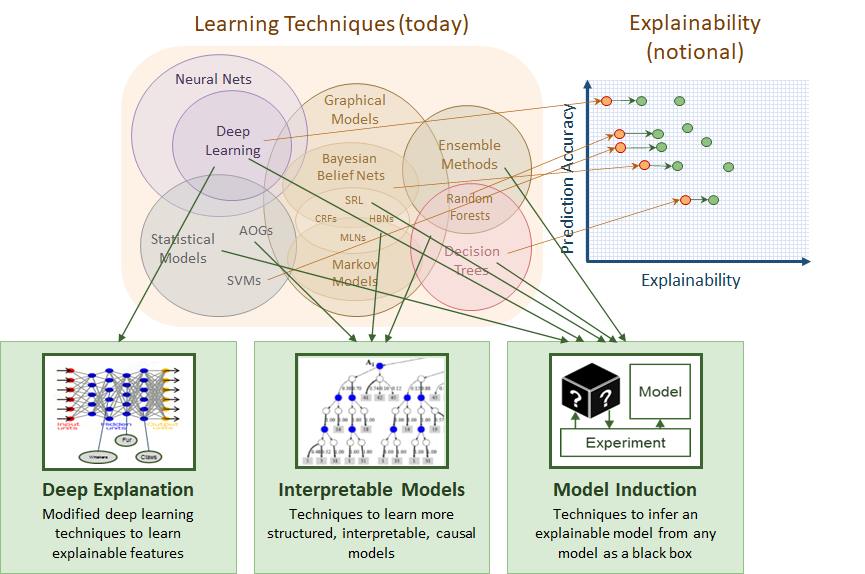

Explanation are part of a social interaction:

- Valid explanations should be sound, cogent, convincing and create trust.
- The receiving party should be able to understand it.
- Step by step transfer of knowledge

Moreover explanations:

- Must show the difference between possible outcomes of decision.
- Should be relevant.
- Can be incomplete. Emphasizing a few examples may be sufficient. No need to be overly complete.
- Should be believable;

XAI in NLP is becoming more important as Large Language models are used for a variety of mission-critical and high-impact applications in our society.

Several overview papers have been written recently, investigating existing approaches for XAI in NLP. Here are two important ones:

1) Analysis Methods in Neural Language Processing: A Survey
Yonatan Belinkov and James Glass. https://direct.mit.edu/tacl/article/doi/10.1162/tacl_a_00254/43503/Analysis-Methods-in-Neural-Language-Processing-A

2) A Survey of the State of Explainable AI for Natural Language Processing
Marina Danilevsky, Kun Qian, Ranit Aharonov, Yannis Katsis, Ban Kawas, Prithviraj Sen. https://arxiv.org/abs/2010.00711

Relevant questions to ask are: what linguistic knowledge is captured by neural networks, why they make certain predictions, if they are robust, interpreting the way they represent language and how they fail.

But how do you explain complex mathematics and machine learning algorithms to individuals that are not familiar with those concepts, let alone, really understand these?

In the following paper, these problems are discussed:

1) The Mythos of Model Interpretability by Zachary C. Lipton. https://arxiv.org/abs/1606.03490

2) DARPA program onExplainable Artificial Intelligence (XAI) by Dr. Matt Turek. https://www.darpa.mil/program/explainable-artificial-intelligence

Both are important to understand psychologfical aspects of "explainability" and "understanding" and different approaches taking in similar situations.

In this tutorial, we will look into a number of examples of methods used to explain the inner workings of AI algorithms in various applications of NLP.

# BERT-Viz

BertViz is an interactive tool for visualizing attention in Transformer language models such as BERT, GPT2, or T5. It can be run inside a Jupyter or Colab notebook through a simple Python API that supports most Huggingface models. BertViz extends the Tensor2Tensor visualization tool by Llion Jones, providing multiple views that each offer a unique lens into the attention mechanism.

We already used these methods in the Deep Learning Transformer Tutorial, but  let's take another look.

In [ ]:
# Cell 1 — safest, minimal install (only bertviz, no dependency resolver)
import importlib, subprocess, sys
if importlib.util.find_spec('bertviz') is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "bertviz==1.4.0"])

print("BertViz installed. Now run Cell 2.")


## The Head View

The head view visualizes attention in one or more heads from a single Transformer layer. Each line shows the attention from one token (left) to another (right). Line weight reflects the attention value (ranges from 0 to 1), while line color identifies the attention head. When multiple heads are selected (indicated by the colored tiles at the top), the corresponding visualizations are overlaid onto one another. For a more detailed explanation of attention in Transformer models, please refer to the blog.

Usage
- Hover over any token on the left/right side of the visualization to filter attention from/to that token.
- Double-click on any of the colored tiles at the top to filter to the corresponding attention head.
- Single-click on any of the colored tiles to toggle selection of the corresponding attention head.
- Click on the Layer drop-down to change the model layer (zero-indexed).

In [ ]:
from bertviz import head_view
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import transformers
transformers.logging.set_verbosity_error()
from datasets import disable_progress_bar
disable_progress_bar()
from transformers import BertTokenizer, BertModel
import torch

MODEL_NAME = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertModel.from_pretrained(MODEL_NAME)
model.eval()

sentence = "BERT makes attention visualization straightforward."

# Tokenize and get attentions at forward pass
inputs = tokenizer.encode_plus(sentence, return_tensors="pt", add_special_tokens=True)
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

# Extract attentions and tokens
# For Transformers >= 4.x: use outputs.attentions; for older: outputs[-1]
attentions = outputs.attentions if hasattr(outputs, "attentions") else outputs[-1]
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# Visualize
head_view(attentions, tokens)



## The Model View
The model view provides a birds-eye view of attention throughout the entire model. Each cell shows the attention weights for a particular head, indexed by layer (row) and head (column). The lines in each cell represent the attention from one token (left) to another (right), with line weight proportional to the attention value (ranges from 0 to 1). For a more detailed explanation, please refer to the blog.

Usage
- Click on any cell for a detailed view of attention for the associated attention head (or to unselect that cell).
- Then hover over any token on the left side of detail view to filter the attention from that token.

In [ ]:
from bertviz import model_view
from transformers import BertTokenizer, BertModel
import torch

MODEL_NAME = "bert-base-uncased"  # works for mBERT too; [SEP] token is the same

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertModel.from_pretrained(MODEL_NAME)
model.eval()

sentence_a = "The teacher explained the concept clearly."
sentence_b = "The students understood the idea."

# Tokenize pair and get attentions
inputs = tokenizer.encode_plus(
    sentence_a,
    sentence_b,
    return_tensors="pt",
    add_special_tokens=True
)
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

# Extract attentions and tokens
attentions = outputs.attentions if hasattr(outputs, "attentions") else outputs[-1]
input_ids = inputs["input_ids"][0]
tokens = tokenizer.convert_ids_to_tokens(input_ids)

# ---- Compute sentence_b_start index ----
# For BERT tokenization: [CLS] A ... [SEP] B ... [SEP]
# sentence B starts immediately after the first [SEP]
sep_token = tokenizer.sep_token  # "[SEP]"
sep_index = tokens.index(sep_token)  # first [SEP]
sentence_b_start = sep_index + 1

# Visualize
model_view(attentions, tokens, sentence_b_start)


# exBERT

ExBERT is another model explaining the innerworkings of Transformers developed by MIT-IBM AI Labs and Harvard NLP Group.

ExBERT does not only provide insight into attention mechanisms, but also combines them with the contextual word embeddings to provide better insight in these important relations as well. According to the authors: "While static analyses of these models lead to targeted insights, interactive tools are more dynamic and can help humans better gain an intuition for the model internal reasoning process. We present EXBERT, an interactive tool named after the popular BERT language model, that provides insights into the meaning of the
contextual representations by matching a human-specified input to similar contexts in a large annotated dataset. By aggregating the annotations of the matching similar contexts, EXBERT helps intuitively explain what each attention-head has learned."

The paper can be found here: https://arxiv.org/pdf/1910.05276.pdf and the source code here: https://github.com/bhoov/exbert

Reference: EXBERT: A Visual Analysis Tool to Explore Learned Representations in Transformers Models. Hoover et al. 2019.




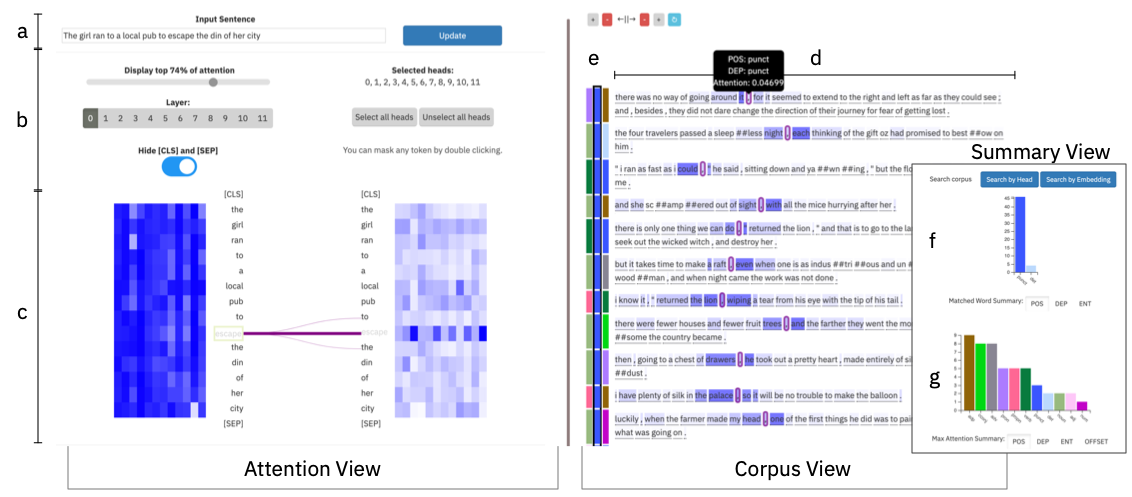

In [ ]:
from IPython.display import IFrame, display, HTML
display(HTML("<style>.output-icon-buttons {display:none}</style>"))  # optional: hide iframe buttons
IFrame("https://exbert.vizhub.ai/client/exBERT.html", width=1100, height=900)
# Copy this link into your browser. it is a hhtp server and not a http, so you will get security warnings.
# Colab does not allow you to access the site directly.


How ExBERT differs from BertViz (and why you might use both)

BertViz (what you already have working) is a notebook-first tool that visualizes attention you pass in; it’s perfect for Colab labs.
GitHub
+1

ExBERT is a web app geared to exploratory analysis and corpus-backed searches (e.g., “find contexts similar to this token’s embedding”) in addition to attention views. It’s the demo from the ACL paper.
aclanthology.org
+1

# pyLDAViz

Topic modelling in natural language processing is a technique which assigns topic to a given corpus based on the words present. In natural language processing, Latent Dirichlet Allocation (LDA) is a generative statistical model that explains a set of observations through unobserved groups, and each group explains why some parts of the data are similar. The LDA is an example of a topic model. In this, observations (e.g., words) are collected into documents, and each word's presence is attributable to one of the document's topics. Each document will contain a small number of topics. See also: https://en.wikipedia.org/wiki/Latent_Dirichlet_allocation

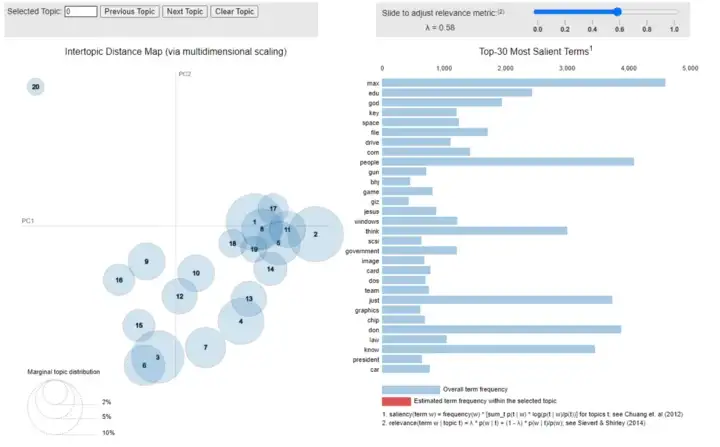

pyLDAViz is a Python Library to visualize topics and related keywords. The gensim implementation of pyLDAviz does not really work (bug in dependencies), however, the skilearn one does works as expected.

Try it yourself with the  code below. Calculating the LDA may take up to 3 minutes.  



In [ ]:
import importlib, subprocess, sys
if importlib.util.find_spec('pyLDAvis') is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "pyLDAvis==3.4.1"])


In [ ]:
import numpy as np
import pyLDAvis

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

# 1) Small dataset (fast)
subset = fetch_20newsgroups(
    subset="train",
    categories=["sci.space", "rec.autos"],
    remove=("headers", "footers", "quotes"),
)
docs = [d for d in subset.data if d and d.strip()][:400]

# 2) Vectorize to DTM
vectorizer = CountVectorizer(
    stop_words='english',
    lowercase=True,
    min_df=5,
    max_df=0.5
)
dtm = vectorizer.fit_transform(docs)              # shape: (n_docs, n_terms)
vocab = vectorizer.get_feature_names_out()        # len = n_terms
term_frequency = np.asarray(dtm.sum(axis=0)).ravel().astype(int)  # (n_terms,)

# 3) Fit LDA (sklearn)
lda = LatentDirichletAllocation(
    n_components=5,
    learning_method="batch",
    random_state=42,
    max_iter=20
)
lda.fit(dtm)

# 4) Build inputs for pyLDAvis.prepare(...)
# topic_term_dists: (n_topics, n_terms), rows sum to 1
topic_term_dists = lda.components_ / lda.components_.sum(axis=1)[:, None]

# doc_topic_dists: (n_docs, n_topics), rows sum to 1
doc_topic_dists = lda.transform(dtm)
doc_topic_dists = doc_topic_dists / doc_topic_dists.sum(axis=1, keepdims=True)

# doc_lengths: total token count per document
doc_lengths = np.asarray(dtm.sum(axis=1)).ravel().astype(int)

# 5) Visualize
pyLDAvis.enable_notebook()
vis = pyLDAvis.prepare(
    topic_term_dists=topic_term_dists,
    doc_topic_dists=doc_topic_dists,
    doc_lengths=doc_lengths,
    vocab=vocab,
    term_frequency=term_frequency,
    mds='pcoa',           # robust in Colab
    sort_topics=False
)
vis

# Post-Hoc XAI Methods

Where BERTViz, exBERT and pyLDAViz provide insight into specific values of local features, connections, weights or (self-)attention, it does not explain us how a decision was made or what the output would have been should we have used other values. Methods that provide more insight in how the model got to it's final decision can be obtained by using Saliency (maps), LIME, or Shapley values.

We will look into these models now. You can find more references on these models below.

Saliency:
- AllenNLP Interpret: A Framework for Explaining Predictions of NLP Models
Eric Wallace et al. 2019. https://arxiv.org/abs/1909.09251
- Explaining Black Box Predictions and Unveiling Data Artifacts
through Influence Functions. Han et al/. 2020.https://arxiv.org/abs/2005.06676
- A Diagnostic Study of Explainability Techniques for Text Classification. Pepa Atanasova et al., 2020. https://aclanthology.org/2020.emnlp-main.263/

Lime:
- "Why Should I Trust You?": Explaining the Predictions of Any Classifier
Marco Tulio Ribeiro, 2016. https://arxiv.org/abs/1602.04938

Sharpley:
- Winter, E. The shapley value. Handbook of game theory
with economic applications, 3:2025–2054, 2002.


## Saliency, FFNN and Hidden Layer Evolution

Let's take a closer look at Saliency models. We'll use the [Inseq library](https://github.com/inseq-team/inseq). To make it work, you need to restart the runtime (since there are conflicting packages with this package and other packages already installed before).


# To make it work, you need to restart the runtime (since there are conflicting packages with this package and other packages already installed before).


In [ ]:
import importlib, subprocess, sys
if importlib.util.find_spec('inseq') is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "inseq"])


In [ ]:
import inseq

model = inseq.load_model("Helsinki-NLP/opus-mt-en-fr", "integrated_gradients")
out = model.attribute(
  "The developer argued with the designer because her idea cannot be implemented.",
  n_steps=100
)
out.show()

In [ ]:
model = inseq.load_model('t5-small', 'integrated_gradients')

# The input movie review
review = """Denis Villeneuve's Dune looks and sounds amazing -- and once the
(admittedly slow-building) story gets you hooked, you'll be on the edge
of your seat for the sequel."""

# Prepend the task to the input text and encode it
input_text = f"sst2 sentence: {review}"

model.attribute(
    input_text,
    generation_args={"max_new_tokens": 1},
).show()


Use a large language model (T5 in this case) to detect text sentiment. In addition to the sentiment, see the tokens the model broke the text into (which can help debug some edge cases).

### Which words in this review lead the model to classify its sentiment as "negative"?

In [ ]:
# Your text
review = """I have a well-documented weakness for sci-fi and expected Dune
to feed my soul. I didn't expect it to entirely blow my mind."""

# Prepend the task to the input text
input_text = f"sst2 sentence: {review}"

model.attribute(
    input_text,
    generation_args={"max_new_tokens": 1}
).show()


Feature attribution using Integrated Gradients helps you explore model decisions. In this case, switching "weakness" to "inclination" allows the model to correctly switch the prediction to *positive*.

### Explore the world knowledge of GPT models by posing fill-in-the blank questions.

In [ ]:
model = inseq.load_model('gpt2', "integrated_gradients")
prompt="""Heathrow airport is located in the city of"""


Does GPT2 know where Heathrow Airport is? Yes. It does.

### What other cities/words did the model consider in addition to London?

In [ ]:
model.attribute(prompt, generation_args={"num_beams": 4, "num_return_sequences": 4, "max_new_tokens": 1}).show()

##LIME

Another type of explainability techniques perturbs the input to find which regions from it change the prediction to a larger degree. One such method is LIME (https://arxiv.org/abs/1602.04938 ), which build a linear local approximator for each instance. It perturbs the input and tries to predict how the output is being changed with each local perturbation. The weights of the linear model for each token are used as saliency scores.

See this book on interpretability (https://christophm.github.io/interpretable-ml-book/lime.html ) for more information on LIME and it's usage in NLP.

LIME can also be used to explain which words contribute most to the polarity in sentiment analysis. See for instance this LIME visualization used to examine the words used for the classification in negation handling. It can be observed that DON'T is notreconized as DON NOT and is this not contributing to the negative polarity of this sentence, hence the positive classification instead of the (correct) negative one.

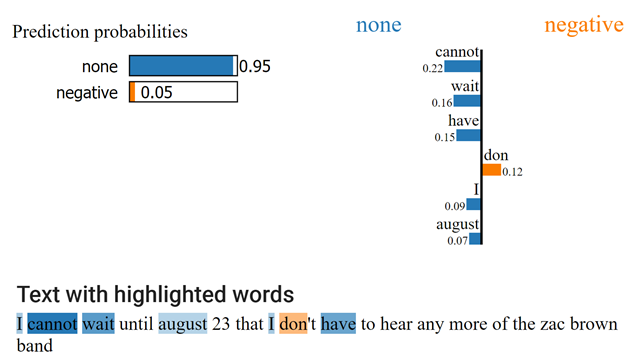



## SHAP (SHapley Additive exPlanations)

SHAP (SHapley Additive exPlanations) is a method based on **Shapley values** from cooperative game theory. It provides a unified framework for interpreting predictions by assigning each feature an importance value for a particular prediction.

### Shapley Values

In cooperative game theory, Shapley values measure the **average marginal contribution** of each player across all possible coalitions. In machine learning, each "player" is a feature, and the "game" is the model's prediction.

For a feature $i$, the Shapley value is:

$$\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!(|N|-|S|-1)!}{|N|!} \left[ f(S \cup \{i\}) - f(S) \right]$$

Where:
- $N$ is the set of all features
- $S$ is a subset of features not including $i$
- $f(S)$ is the model prediction using only features in $S$

### SHAP in NLP

SHAP can be applied to NLP models to understand **which tokens contribute most to a prediction**. For text classification:

1. **Each word/token** in the input is treated as a "player"
2. SHAP computes how much each token contributes to the model's prediction
3. Positive SHAP values push toward one class, negative toward another

### SHAP vs LIME

| Aspect | LIME | SHAP |
|---|---|---|
| **Theory** | Local linear approximation | Game-theoretic (Shapley values) |
| **Guarantees** | No formal guarantees | Satisfies efficiency, symmetry, dummy, additivity axioms |
| **Consistency** | May give different results on reruns | Mathematically consistent |
| **Speed** | Fast (fewer perturbations needed) | Slower (exponential subsets, approximated in practice) |
| **Global view** | Local only | Can aggregate to global feature importance |

Both LIME and SHAP are **model-agnostic** and **perturbation-based**, making them versatile tools for explaining any NLP classifier. SHAP's theoretical guarantees make it more reliable, while LIME's speed makes it more practical for quick explorations.

Reference: Lundberg, S.M. & Lee, S.I. "A Unified Approach to Interpreting Model Predictions." NeurIPS 2017.

In [ ]:
# SHAP for text classification
# Note: SHAP can be slow for large models; we use a small pipeline here
import importlib, subprocess, sys
if importlib.util.find_spec('shap') is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])

import shap
from transformers import pipeline

# Load sentiment classifier
classifier = pipeline("text-classification",
                     model="distilbert-base-uncased-finetuned-sst-2-english",
                     return_all_scores=True)

# Create SHAP explainer
explainer = shap.Explainer(classifier)

# Explain a few examples
texts = [
    "The movie was absolutely wonderful and moving.",
    "Terrible acting and a boring plot made this unwatchable."
]

shap_values = explainer(texts)

# Visualize SHAP values
shap.plots.text(shap_values)

## Adversarial Attacks in NLP

As we discussed in the lecture, NLP is also subject to adversarial attacks. An adversarial attacks applies a small, well-chosen perturbation to an text to fool an image classifier.

Various methods exist to implement an adversarial attack (https://en.wikipedia.org/wiki/Adversarial_machine_learning ), there are also various methods for defense and detection.

Most used adversarial attacks in NLP are related to abuse the notion of linguistic similarity:
- Morphological (aka visual):  use an adversarial example to be a text sequence that looks very similar to the original input, but changes a few characters and receives very different prediction.
- Semantical: the perturbation is a semantically indistinguishable paraphrase of the original input, but the input and perturbation receive different predictions.

A well known Python libary to create adversarial attacks is TextAttack: https://github.com/QData/TextAttack. You can find several code examples on the internet.Unfortunately, this library is causing huge dependency pains on Colab. So, here we will present a simple, robust alternative that works with the stock Colab stack and demonstrates everything you asked for:

* a small adversary implementation (no external attack lib),

* an attack success evaluation,

* LIME-based detection (compare token importances before/after),

* a tiny adversarial-augmentation defense (re-fine-tune a classifier briefly).

All code below is copy-paste ready for a Colab cell sequence. It uses only transformers, nltk, and lime (light installs) and avoids textattack entirely.

**BEFORE YOU RUN THIS CODE, RESET THE RUNTIME AND COMPLETELY RESTART COLAB, OTHERWISE YOU WILL RUN INTO DEPENDENCY ISSUES. **

First we will load NTLK with the Wordnet synonym collection.

In [ ]:
!pip -q install transformers==4.35.0 torch --upgrade
!pip -q install nltk

import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')


Next, we will load a simple BERT model fine tuned for sentiment mining using the SST2 data set.

In [ ]:
from transformers import pipeline
import random
import nltk
from nltk.corpus import wordnet as wn
import re

# --- Choose a model (try these):
# MODEL_NAME = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"   # your baseline (robust)
MODEL_NAME = "sadhaklal/bert-base-uncased-finetuned-sst2-v2"   # often brittle
# MODEL_NAME = "yoshitomo-matsubara/bert-base-uncased-sst2"    # alternative

pipe = pipeline("sentiment-analysis", MODEL_NAME)

def predict(text):
    out = pipe(text)[0]
    # normalize output to polarity label and score
    label = out['label']
    score = float(out['score'])
    return label, score

# simple tokenizer to help with swapping whole words
_WORD_RE = re.compile(r"\w+|[^\w\s]", re.UNICODE)

def synonym_swap(text, n_swaps=1):
    """Replace up to n_swaps nouns/adjectives/verbs/adverbs with WordNet synonyms (simple)."""
    tokens = _WORD_RE.findall(text)
    # choose candidate token indices that are alphabetic and not stopwords
    cand_idxs = [i for i,t in enumerate(tokens) if t.isalpha() and len(t) > 2]
    random.shuffle(cand_idxs)
    swaps = 0
    for i in cand_idxs:
        w = tokens[i]
        syns = []
        for syn in wn.synsets(w):
            for l in syn.lemmas():
                candidate = l.name().replace('_',' ')
                if candidate.lower() != w.lower() and candidate.isalpha():
                    syns.append(candidate)
        syns = list(dict.fromkeys(syns))
        if syns:
            tokens[i] = random.choice(syns)
            swaps += 1
        if swaps >= n_swaps:
            break
    return "".join([ (t if re.match(r'\w+',t) else t) for t in tokens ])

def inject_typo(text, n_typos=1):
    """Random simple typos: character swap / deletion / insertion in random words."""
    tokens = _WORD_RE.findall(text)
    word_idx = [i for i,t in enumerate(tokens) if t.isalpha() and len(t)>2]
    if not word_idx:
        return text
    for _ in range(n_typos):
        i = random.choice(word_idx)
        w = list(tokens[i])
        op = random.choice(['swap','del','ins'])
        if op == 'swap' and len(w) >= 2:
            j = random.randrange(len(w)-1)
            w[j], w[j+1] = w[j+1], w[j]
        elif op == 'del' and len(w) >= 2:
            del w[random.randrange(len(w))]
        else:  # insert a random letter
            w.insert(random.randrange(len(w)+1), random.choice('aeiou'))
        tokens[i] = "".join(w)
    return "".join([ (t if re.match(r'\w+',t) else t) for t in tokens ])


# quick demo function that tries a few perturbations and returns flips
def find_flip(orig_text, max_trials=40):
    orig_label, orig_score = predict(orig_text)
    results = []
    for t in range(max_trials):
        if t % 2 == 0:
            cand = synonym_swap(orig_text, n_swaps=random.randint(1,2))
            attack_type = "synonym"
        else:
            cand = inject_typo(orig_text, n_typos=random.randint(1,2))
            attack_type = "typo"
        lab, sc = predict(cand)
        results.append((attack_type, cand, lab, sc))
        if lab != orig_label:
            return {"orig":(orig_text,orig_label,orig_score), "attack":(attack_type,cand,lab,sc)}
    return {"orig":(orig_text,orig_label,orig_score), "attack":None, "tried":results[:10]}

# quick test
s = "I absolutely loved this movie, it was delightful and moving."
print("Original prediction:", predict(s))
res = find_flip(s)
print(res)


Now let's try to confuse the models with some simple adversarial attacks.

In [ ]:
examples = [
    "I absolutely loved this movie, it was delightful and moving.",
    "An unexpected gem; charming performance and witty dialogue."
]

for ex in examples:
    print("-"*60)
    print("INPUT:", ex)
    print("BASE PRED:", predict(ex))
    out = find_flip(ex, max_trials=50)
    if out["attack"] is None:
        print("No flip found in 50 trials (showing some tried attacks):")
        for ttype,txt,lab,sc in out.get("tried",[]):
            print(f"  [{ttype}] -> {lab} ({sc:.3f}) : {txt}")
    else:
        atype, txt, lab, sc = out["attack"]
        print(f"Found flip with [{atype}] -> {lab} ({sc:.3f})")
        print("ADV TEXT:", txt)


This demonstrates that simple edits (synonym swaps or typos) can flip predictions for some sentences.

# How LIME can be used to detect adversarial sensitivity (short explanation)

LIME (Local Interpretable Model-agnostic Explanations) explains a model’s prediction by showing how individual features (in NLP: tokens or words) contribute to the decision.

To detect adversarial sensitivity in sentiment classifiers (e.g., BERT sentiment models), you do this:

* Run LIME on the original sentence.
LIME highlights the words that drive the predicted sentiment (positive or negative), showing how much each token contributes.

* Apply an adversarial attack (e.g., small typo or synonym substitution).

* Run LIME again on the perturbed sentence.
If the model is adversarially sensitive, the LIME explanation suddenly shifts: words that previously contributed positively may lose weight, or a harmless synonym or typo may flip the sentiment contribution, or
the model starts relying on irrelevant tokens.

The change in the LIME heatmap / bar chart reveals that the model’s decision boundary is fragile: tiny text changes cause big changes in explanations and classification outcome — even if humans perceive the meaning as identical.

# Example (mock LIME-style token contribution visualization)

This is an illustrative “screenshot-style” bar chart showing token contributions for the sentence:

“I absolutely loved this movie, it was delightful.”

In this mock example, the word “boring” (inserted by an adversarial synonym swap) flips the model prediction because it gets a strong negative weight.


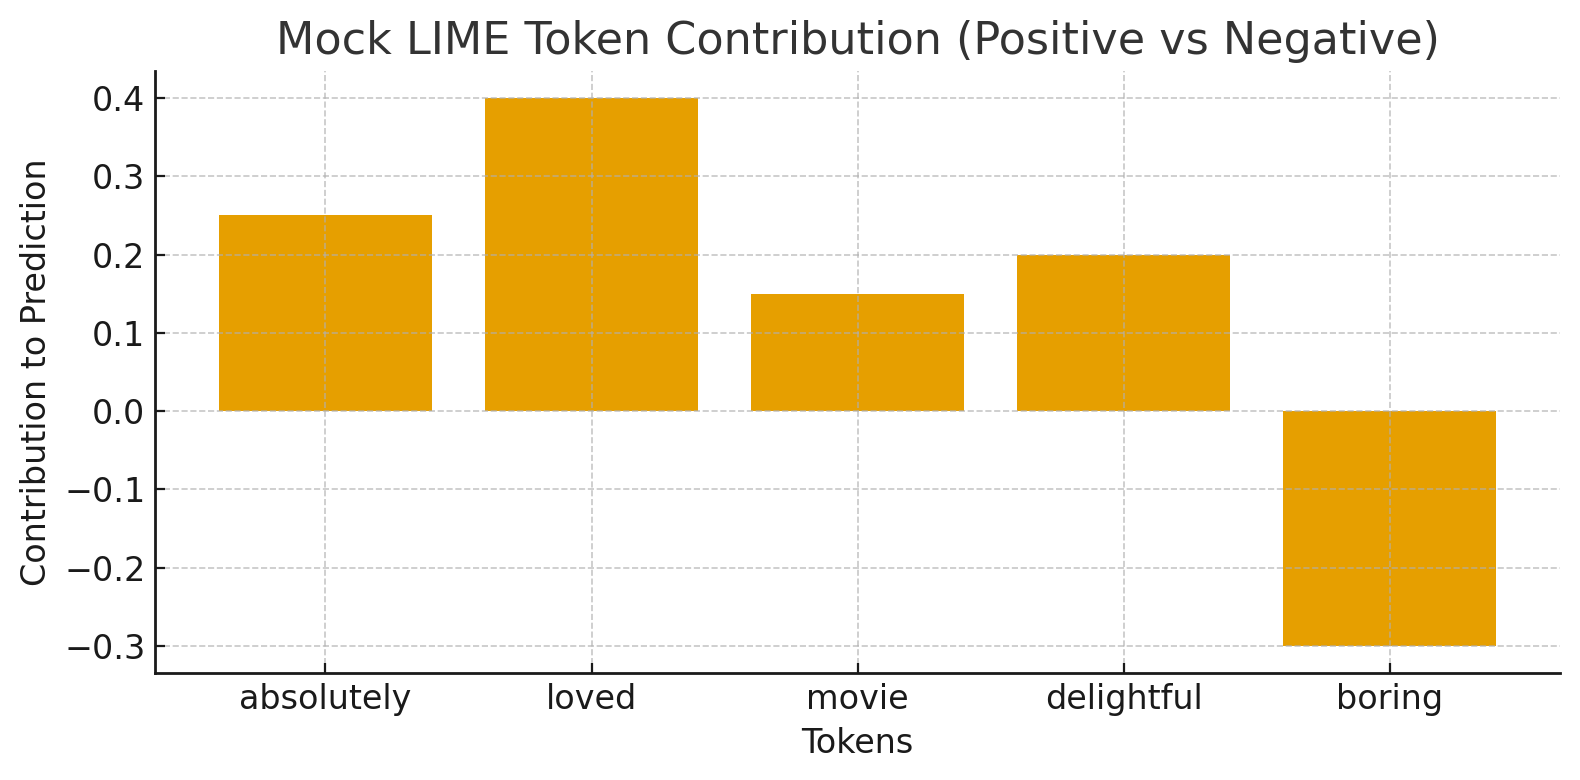

## AI in NLP Explanations in NLP

Natural language explanations can also be used to explain the behavior of an AI model. The explanation is then verbalized in human-comprehensible natural language. The NLP explaining the model’s behavior is explained by a generative model, or even a dialog Q&A model being able to answer questions on the model’s behavior.

A few references can be found here:

- e-SNLI: Natural Language Inference with Natural Language Explanations (Camburu et al., NeurIPS’18) https://arxiv.org/abs/1812.01193
- Make Up Your Mind! Adversarial Generation of Natural Language Explanations (Camburu et al., ACL’20)  
- NILE: Natural Language Inference with Faithful Natural Language Explanations (Kumar and Talukdar, ACL’20)
- Rationale-Inspired Natural Language Explanations with Commonsense (Majumder et al., 2021)

A verbal export or desciption of the results from BERTViz, LIME or Shapley could be used to write a prompt or even start a dialog in ChatGPT. This is an interesting topic for future research or internships!

## Take Away

### Key Concepts

1. **XAI** (eXplainable AI) aims to make model decisions transparent, interpretable, and explainable to humans.

2. **Attention Visualization** (BERTViz, exBERT) reveals *how* Transformer models process information internally -- which tokens attend to which, and how attention patterns evolve across layers.

3. **Feature Attribution** methods (Saliency/Integrated Gradients, Inseq) identify *which input features* are most important for a specific prediction by computing gradient-based importance scores.

4. **Perturbation-based** methods (LIME, SHAP) explain predictions by observing how outputs change when inputs are perturbed. LIME fits local linear models; SHAP uses game-theoretic Shapley values for mathematically grounded explanations.

5. **Adversarial Attacks** demonstrate model vulnerabilities by finding small input perturbations that change predictions -- motivating the need for robust models and XAI-based detection methods.

### Method Comparison

| Method | Type | Explains | Model-Agnostic? |
|---|---|---|---|
| **BERTViz** | Attention visualization | Internal attention patterns | No (Transformers only) |
| **Inseq/Saliency** | Gradient-based attribution | Input feature importance | No (differentiable models) |
| **LIME** | Perturbation-based | Local prediction behavior | Yes |
| **SHAP** | Perturbation-based (Shapley) | Local + global importance | Yes |
| **Adversarial Analysis** | Perturbation-based | Model robustness/fragility | Yes |

### Practical Advice

- Use **multiple XAI methods** together for a more complete picture of model behavior.
- **Attention ≠ explanation**: high attention does not always mean a token is causally important for the prediction.
- Choose **SHAP over LIME** when you need consistent, theoretically grounded explanations; use **LIME** for quick explorations.
- Always consider **adversarial robustness** when deploying NLP models in production.

# Exercises

## Exercise A1: XAI using Saliency Methods (10 points)

Using the saliency demonstrations above (Inseq library with Integrated Gradients):

**a)** (5 points) Choose **two different input texts** and run saliency analysis on them using the code from the tutorial. Present the key tokens with highest attribution scores for each input in a short table.

**b)** (5 points) How do gradient-based saliency maps differ from attention-based explanations (BERTViz)? Summarize the key differences, advantages, and limitations in a comparison table.

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: LIME and SHAP for XAI in NLP (15 points)

**a)** (5 points - code) The LIME pipeline is set up below. Add **two input texts** (one positive, one negative) and generate LIME explanations for both. Display the top contributing words.

**b)** (5 points - explanation) What do LIME explanations reveal compared to saliency methods and BERTViz? Summarize in a short comparison.

**c)** (5 points - explanation) Compare LIME and SHAP: what are the key trade-offs? When would you prefer one over the other?

In [ ]:
# LIME pipeline setup (provided)
from transformers import pipeline
import numpy as np
from lime.lime_text import LimeTextExplainer
from IPython.display import display, HTML

clf = pipeline("text-classification",
               model="distilbert-base-uncased-finetuned-sst-2-english",
               return_all_scores=True)
class_names = ["NEGATIVE", "POSITIVE"]

def predict_proba(texts):
    all_scores = clf(texts)
    probs = []
    for scores in all_scores:
        d = {s["label"]: s["score"] for s in scores}
        probs.append([d.get("NEGATIVE", 0.0), d.get("POSITIVE", 0.0)])
    return np.array(probs)

explainer = LimeTextExplainer(class_names=class_names)

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A2 (5 points)
assert 'explainer' in dir(), "LimeTextExplainer must be created"
assert 'exp_pos' in dir(), "LIME explanation for positive text must exist"
assert 'exp_neg' in dir(), "LIME explanation for negative text must exist"
assert len(exp_pos.as_list(label=pred_pos)) > 0, "Positive explanation must have features"
assert len(exp_neg.as_list(label=pred_neg)) > 0, "Negative explanation must have features"
print("All A2 code tests passed!")

**b) and c) Write your answers below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: Adversarial Attacks in NLP (20 points)

The adversarial attack functions from the tutorial (`find_flip`, synonym substitution, typos) are available above.

**a)** (5 points - code) Use the attack code to test **at least 5 sentences** (mix of positive and negative). Report the original prediction, attack type, and whether the prediction flipped. The scaffold is provided below.

**b)** (5 points - explanation) Which attack type (synonym swap vs typo) was more successful? Why?

**c)** (10 points - explanation) How can XAI methods (LIME/SHAP) help **detect** adversarial attacks? Describe a detection approach and discuss how robust models could be built to resist such attacks.

In [ ]:
# Attack scaffold (provided) — uses find_flip and predict from the tutorial above
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A3 (5 points)
assert isinstance(test_sentences, list), "test_sentences must be a list"
assert len(test_sentences) >= 5, "Must test at least 5 sentences"
assert isinstance(attack_results, list), "attack_results must be a list"
assert len(attack_results) == len(test_sentences), "Must have results for all sentences"
print(f"Tested {len(test_sentences)} sentences, {total_flips} flipped")
print("All A3 code tests passed!")

**b) and c) Write your answers below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## References

- BERTViz: Vig, J. "A Multiscale Visualization of Attention in the Transformer Model." ACL 2019. https://github.com/jessevig/bertviz
- exBERT: Hoover, B., Strobelt, H., Gehrmann, S. "exBERT: A Visual Analysis Tool to Explore Learned Representations in Transformers Models." ACL 2020. https://github.com/bhoov/exbert
- pyLDAvis: Sievert, C. & Shirley, K. "LDAvis: A method for visualizing and interpreting topics." ACL Workshop on Interactive Language Learning, Visualization, and Interfaces, 2014.
- Inseq: Sarti, G. et al. "Inseq: An Interpretability Toolkit for Sequence Generation Models." ACL 2023. https://github.com/inseq-team/inseq
- LIME: Ribeiro, M.T., Singh, S., Guestrin, C. "Why Should I Trust You? Explaining the Predictions of Any Classifier." KDD 2016.
- SHAP: Lundberg, S.M. & Lee, S.I. "A Unified Approach to Interpreting Model Predictions." NeurIPS 2017. https://github.com/slundberg/shap
- Jain, S. & Wallace, B.C. "Attention is not Explanation." NAACL 2019.
- Camburu, O.M. et al. "e-SNLI: Natural Language Inference with Natural Language Explanations." NeurIPS 2018.
- TextAttack: Morris, J.X. et al. "TextAttack: A Framework for Adversarial Attacks, Data Augmentation, and Adversarial Training in NLP." EMNLP 2020. https://github.com/QData/TextAttack
- XAI Resources: https://ex.pegg.io/